### Import Library

In [ ]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from matplotlib import font_manager, rc
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

### Data Analysis

/var/folders/pc/0_qqcqxd1fncd71rzs72fhr00000gn/T/ipykernel_31582/1700700692.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("../../data/CaseStudy/KR_jeju.csv", index_col=0, parse_dates=True).T["2010.1.15":"2020.7.15"]


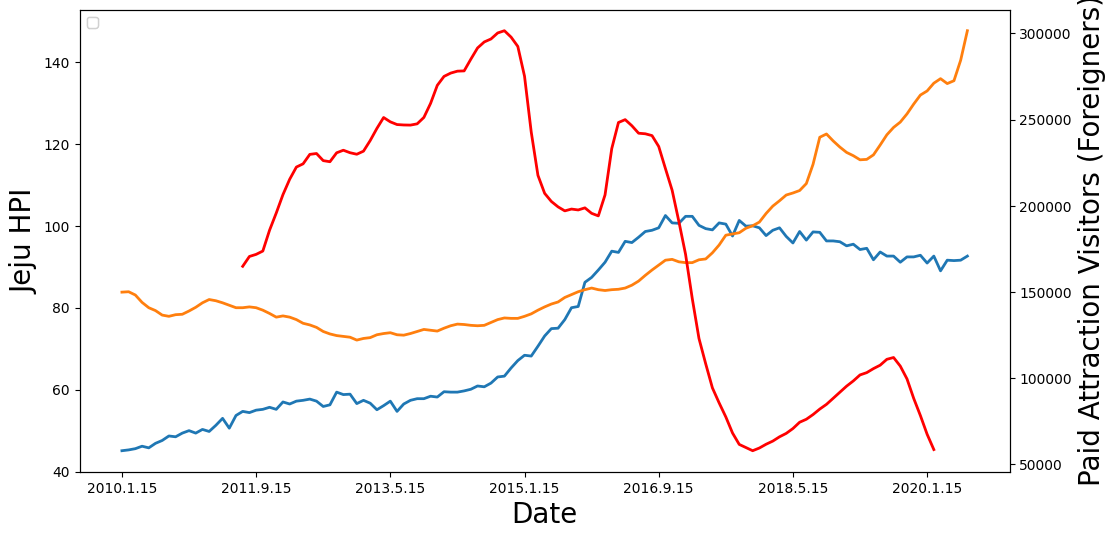

In [ ]:
# 1) Read CSV
df = pd.read_csv("../../data/CaseStudy/KR_jeju.csv", index_col=0, parse_dates=True).T["2010.1.15":"2020.7.15"]
left_cols  = ["Jeju_HPI","Seoul_HPI"]     
right_cols = ["Paid Attraction Visitors (Foreigners)"] 


fig, ax = plt.subplots(figsize=(12, 6))

df[left_cols].plot(ax=ax, linewidth=2)
ax.set_ylabel("Jeju HPI", fontsize=20)

ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)

ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")

plt.show()


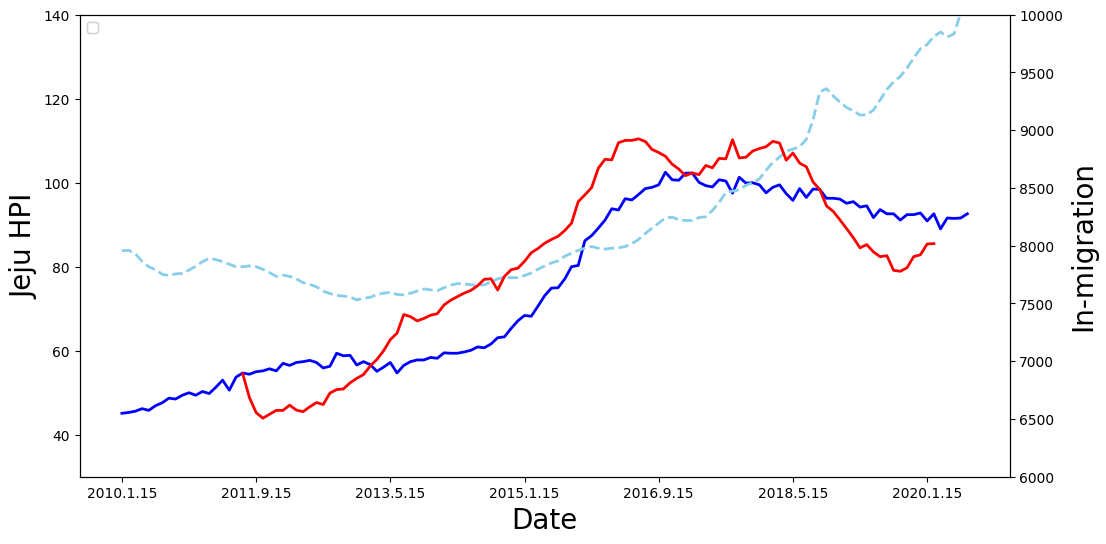

In [ ]:
right_cols = ["In-migration"]

fig, ax = plt.subplots(figsize=(12, 6))

df["Jeju_HPI"].plot(ax=ax, linewidth=2, color="blue")
ax.set_ylabel("Jeju HPI", fontsize=20)

ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
df["Seoul_HPI"].plot(ax=ax, linestyle="--", linewidth=2,color="skyblue")
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)

ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")
ax.set_ylim(30, 140)
ax2.set_ylim(6000, 10000)
plt.show()

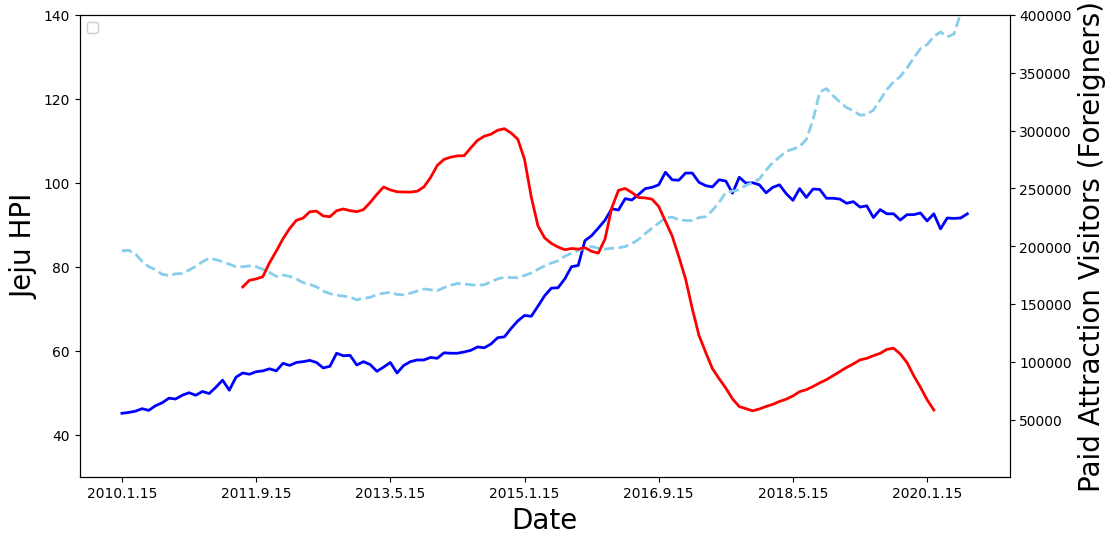

In [4]:
right_cols = ["Paid Attraction Visitors (Foreigners)"]

fig, ax = plt.subplots(figsize=(12, 6))

df["Jeju_HPI"].plot(ax=ax, linewidth=2, color="blue")
ax.set_ylabel("Jeju HPI", fontsize=20)

ax2 = ax.twinx()
ax2.set_ylabel(right_cols[0], fontsize=20)
df["Seoul_HPI"].plot(ax=ax, linestyle="--", linewidth=2,color="skyblue")
df[right_cols].rolling(window=12, center=True).mean().plot(ax=ax2, color="red", linewidth=2)

ax.set_xlabel("Date", fontsize=20)
ax.legend("", loc="upper left")
ax2.legend("", loc="upper left")
ax.set_ylim(30, 140)
ax2.set_ylim(1000, 400000)
plt.show()

In [5]:
df["Paid Attraction Visitors (Foreigners) ma"] = df["Paid Attraction Visitors (Foreigners)"].rolling(window=12, center=True).mean()
df["In-migration ma"] = df["In-migration"].rolling(window=12, center=True).mean()

In [6]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

data = df[["Jeju_HPI", "Paid Attraction Visitors (Foreigners) ma"]].diff().dropna() 

maxlag = 30

results = grangercausalitytests(data, maxlag=maxlag, verbose=True)

print(f"\n{'lag':<5}  {'ssr F p-value':>15}")
for lag, res in results.items():
    p_value = res[0]['ssr_ftest'][1]
    print(f"{lag:<5}  {p_value:>15.4f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1297  , p=0.7195  , df_denom=99, df_num=1
ssr based chi2 test:   chi2=0.1336  , p=0.7147  , df=1
likelihood ratio test: chi2=0.1335  , p=0.7148  , df=1
parameter F test:         F=0.1297  , p=0.7195  , df_denom=99, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1082  , p=0.8976  , df_denom=96, df_num=2
ssr based chi2 test:   chi2=0.2277  , p=0.8924  , df=2
likelihood ratio test: chi2=0.2274  , p=0.8925  , df=2
parameter F test:         F=0.1082  , p=0.8976  , df_denom=96, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.2023  , p=0.8946  , df_denom=93, df_num=3
ssr based chi2 test:   chi2=0.6525  , p=0.8843  , df=3
likelihood ratio test: chi2=0.6504  , p=0.8848  , df=3
parameter F test:         F=0.2023  , p=0.8946  , df_denom=93, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=0.1400  , p=0.9669  , df_d

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [7]:
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests

data = df[["Jeju_HPI", "In-migration ma"]].diff().dropna() 

maxlag = 12

results = grangercausalitytests(data, maxlag=maxlag, verbose=True)

print(f"\n{'lag':<5}  {'ssr F p-value':>15}")
for lag, res in results.items():
    p_value = res[0]['ssr_ftest'][1]
    print(f"{lag:<5}  {p_value:>15.4f}")



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=19.5071 , p=0.0000  , df_denom=99, df_num=1
ssr based chi2 test:   chi2=20.0982 , p=0.0000  , df=1
likelihood ratio test: chi2=18.3450 , p=0.0000  , df=1
parameter F test:         F=19.5071 , p=0.0000  , df_denom=99, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=9.7675  , p=0.0001  , df_denom=96, df_num=2
ssr based chi2 test:   chi2=20.5524 , p=0.0000  , df=2
likelihood ratio test: chi2=18.7077 , p=0.0001  , df=2
parameter F test:         F=9.7675  , p=0.0001  , df_denom=96, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.8020  , p=0.0011  , df_denom=93, df_num=3
ssr based chi2 test:   chi2=18.7160 , p=0.0003  , df=3
likelihood ratio test: chi2=17.1564 , p=0.0007  , df=3
parameter F test:         F=5.8020  , p=0.0011  , df_denom=93, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.7138  , p=0.0076  , df_d

/Users/yeojisu/opt/anaconda3/envs/cv2024/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
